# Fase 2 v4 — NB03: Detección de aspectos — Diccionario vs SBERT

Compara dos métodos de **Aspect Category Detection** (¿qué aspectos menciona la reseña?)
contra el gold consolidado, de forma honesta:
- **Diccionario** (léxico editable, sin tuneo).
- **SBERT zero-shot** (similitud semántica reseña–prototipo de aspecto).

**Metodología sin sesgo:**
- Se valida sobre el **Pool A (representativo)**, no sobre el minado.
- Pool A se parte en **dev** (tunear el umbral de SBERT) y **test** (reportar).
- Ambos métodos se reportan en el **mismo test**. El diccionario no se tunea.

*No se clasifica polaridad aquí (eso es NB04).*

## 1. Carga del gold (Pool A) y split dev/test

In [1]:
import json, re, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)
BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
GOLD_DIR = BASE_DIR / "outputs" / "gold"
OUT_DIR = BASE_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ASPECTOS = ["atractivos", "costos", "seguridad", "accesibilidad",
            "limpieza", "atencion_servicio", "gastronomia", "alojamiento"]

# Gold ANCHO; nos quedamos con Pool A (representativo) para validar detección sin sesgo léxico.
gold = pd.read_csv(GOLD_DIR / "gold_consolidado.csv", encoding="utf-8-sig")
gold = gold[gold["pool"] == "A_representativo"].copy().reset_index(drop=True)

# Ground truth de PRESENCIA: aspecto presente = etiqueta != ausente (y != sin_consenso)
for a in ASPECTOS:
    gold[f"gt_{a}"] = (~gold[a].isin(["ausente", "sin_consenso"])).astype(int)

# Split dev/test (50/50)
gold = gold.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n_dev = len(gold) // 2
dev, test = gold.iloc[:n_dev].copy(), gold.iloc[n_dev:].copy()
print(f"Pool A: {len(gold)} reseñas | dev: {len(dev)} | test: {len(test)}")
print("Presencia por aspecto (gold, Pool A completo):")
print(gold[[f"gt_{a}" for a in ASPECTOS]].sum().rename(lambda c: c[3:]).to_string())

Pool A: 600 reseñas | dev: 300 | test: 300
Presencia por aspecto (gold, Pool A completo):
atractivos           545
costos               143
seguridad             25
accesibilidad        182
limpieza              52
atencion_servicio    168
gastronomia           37
alojamiento           38


## 2. Método 1 — Diccionario

In [2]:
# ============================================================
# MÉTODO 1 — DICCIONARIO (léxico editable)
# ============================================================
ASPECT_KEYWORDS = json.load(open(DATA_DIR / "diccionario_aspectos.json", encoding="utf-8"))
ASPECT_KEYWORDS = {k: v for k, v in ASPECT_KEYWORDS.items() if not str(k).startswith("_") and isinstance(v, list)}

def normalize_for_detection(text):
    text = unicodedata.normalize("NFKD", str(text).lower())
    text = "".join(c for c in text if not unicodedata.combining(c))
    text = re.sub(r"[^a-z0-9ñ\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def _patron(kw):
    raiz = kw.endswith("*")
    base = normalize_for_detection(kw.rstrip("*"))
    if not base:
        return None
    return r"(?<!\w)" + re.escape(base) + (r"\w*" if raiz else r"(?!\w)")

_PATRONES = {a: [p for p in (_patron(k) for k in kws) if p] for a, kws in ASPECT_KEYWORDS.items()}

def detectar_dict(text):
    t = normalize_for_detection(text)
    return {a: int(any(re.search(p, t) for p in pats)) for a, pats in _PATRONES.items()}

dict_pred = test["text_clean"].apply(detectar_dict).apply(pd.Series)
print("Diccionario aplicado al test:", dict_pred.shape)

Diccionario aplicado al test: (300, 8)


## 3. Método 2 — SBERT zero-shot

In [3]:
# ============================================================
# MÉTODO 2 — SBERT ZERO-SHOT (similitud semántica)
# ============================================================
from sentence_transformers import SentenceTransformer, util

MODELO = "paraphrase-multilingual-mpnet-base-v2"
print("Cargando", MODELO, "...")
sbert = SentenceTransformer(MODELO)

# Prototipo por aspecto = media de embeddings de una descripción + los términos del diccionario.
DESCRIPCION = {
    "atractivos": "los atractivos turísticos, paisajes, ruinas, vistas y belleza del lugar",
    "costos": "el precio, el costo de la entrada, si es caro o barato y si vale la pena",
    "seguridad": "la seguridad, robos, asaltos o peligro en el lugar",
    "accesibilidad": "el acceso, el transporte, los caminos, escaleras y cómo llegar",
    "limpieza": "la limpieza, los baños, la basura y la higiene del lugar",
    "atencion_servicio": "la atención, el servicio, el trato del personal y los guías",
    "gastronomia": "la comida, los restaurantes, los platos y la gastronomía",
    "alojamiento": "el hospedaje, el hotel, las habitaciones y el alojamiento",
}
def semillas(a):
    kws = [k.rstrip("*") for k in ASPECT_KEYWORDS.get(a, [])][:25]
    return [DESCRIPCION[a]] * 3 + [a] + kws   # la descripción pesa más

prototipos = np.vstack([sbert.encode(semillas(a), normalize_embeddings=True).mean(axis=0) for a in ASPECTOS])
prototipos = prototipos / np.linalg.norm(prototipos, axis=1, keepdims=True)

def sims(df):
    emb = sbert.encode(df["text_clean"].tolist(), normalize_embeddings=True, show_progress_bar=False)
    return np.asarray(util.cos_sim(emb, prototipos))   # n x 8

sim_dev, sim_test = sims(dev), sims(test)

# Tunear umbral POR ASPECTO en dev (maximiza F1 de presencia)
def f1_bin(y, yhat):
    tp = int(((y == 1) & (yhat == 1)).sum()); fp = int(((y == 0) & (yhat == 1)).sum()); fn = int(((y == 1) & (yhat == 0)).sum())
    p = tp / (tp + fp) if tp + fp else 0.0; r = tp / (tp + fn) if tp + fn else 0.0
    return 2 * p * r / (p + r) if p + r else 0.0

umbrales = {}
for j, a in enumerate(ASPECTOS):
    y = dev[f"gt_{a}"].values
    best_t, best_f1 = 0.3, -1
    for t in np.arange(0.05, 0.65, 0.025):
        f1 = f1_bin(y, (sim_dev[:, j] >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, round(float(t), 3)
    umbrales[a] = best_t
print("Umbrales SBERT por aspecto (tuneados en dev):", umbrales)

sbert_pred = pd.DataFrame({a: (sim_test[:, j] >= umbrales[a]).astype(int) for j, a in enumerate(ASPECTOS)}, index=test.index)

Cargando paraphrase-multilingual-mpnet-base-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Umbrales SBERT por aspecto (tuneados en dev): {'atractivos': 0.1, 'costos': 0.275, 'seguridad': 0.225, 'accesibilidad': 0.25, 'limpieza': 0.35, 'atencion_servicio': 0.2, 'gastronomia': 0.325, 'alojamiento': 0.325}


## 4. Evaluación en test

In [4]:
# ============================================================
# EVALUACIÓN EN TEST — diccionario vs SBERT
# ============================================================
def metricas(pred):
    filas = []
    for a in ASPECTOS:
        y = test[f"gt_{a}"].values; yh = pred[a].values
        tp = int(((y==1)&(yh==1)).sum()); fp=int(((y==0)&(yh==1)).sum()); fn=int(((y==1)&(yh==0)).sum())
        p = tp/(tp+fp) if tp+fp else 0.0; r = tp/(tp+fn) if tp+fn else 0.0
        f1 = 2*p*r/(p+r) if p+r else 0.0
        filas.append({"aspecto": a, "P": round(p,3), "R": round(r,3), "F1": round(f1,3), "soporte": int((y==1).sum())})
    df = pd.DataFrame(filas)
    macro = {"aspecto":"MACRO","P":round(df["P"].mean(),3),"R":round(df["R"].mean(),3),"F1":round(df["F1"].mean(),3),"soporte":int(df["soporte"].sum())}
    return pd.concat([df, pd.DataFrame([macro])], ignore_index=True)

m_dict = metricas(dict_pred)
m_sbert = metricas(sbert_pred)

comp = m_dict.merge(m_sbert, on="aspecto", suffixes=("_dict", "_sbert"))[
    ["aspecto","F1_dict","F1_sbert","P_dict","P_sbert","R_dict","R_sbert","soporte_dict"]
].rename(columns={"soporte_dict":"soporte"})
comp["gana"] = np.where(comp["F1_sbert"]>comp["F1_dict"],"SBERT",np.where(comp["F1_sbert"]<comp["F1_dict"],"diccionario","empate"))
print("F1 macro — diccionario:", m_dict[m_dict.aspecto=="MACRO"]["F1"].iloc[0], "| SBERT:", m_sbert[m_sbert.aspecto=="MACRO"]["F1"].iloc[0])
display(comp)
comp.to_csv(OUT_DIR / "comparacion_diccionario_vs_sbert.csv", index=False, encoding="utf-8-sig")

F1 macro — diccionario: 0.8 | SBERT: 0.406


,aspecto,F1_dict,F1_sbert,P_dict,P_sbert,R_dict,R_sbert,soporte,gana
0,atractivos,0.957,0.951,0.977,0.906,0.937,1.000,271,diccionario
1,costos,0.842,0.612,0.762,0.487,0.941,0.824,68,diccionario
2,seguridad,0.519,0.111,0.389,0.060,0.778,0.778,9,diccionario
3,accesibilidad,0.893,0.469,0.888,0.312,0.898,0.943,88,diccionario
4,limpieza,0.828,0.361,0.750,0.283,0.923,0.500,26,diccionario
5,atencion_servicio,0.879,0.400,0.812,0.252,0.958,0.972,72,diccionario
6,gastronomia,0.593,0.276,0.421,0.190,1.000,0.500,16,diccionario
7,alojamiento,0.889,0.068,0.923,0.037,0.857,0.357,14,diccionario
8,MACRO,0.800,0.406,0.740,0.316,0.912,0.734,564,diccionario


## Visualizaciones (figuras para la tesis)

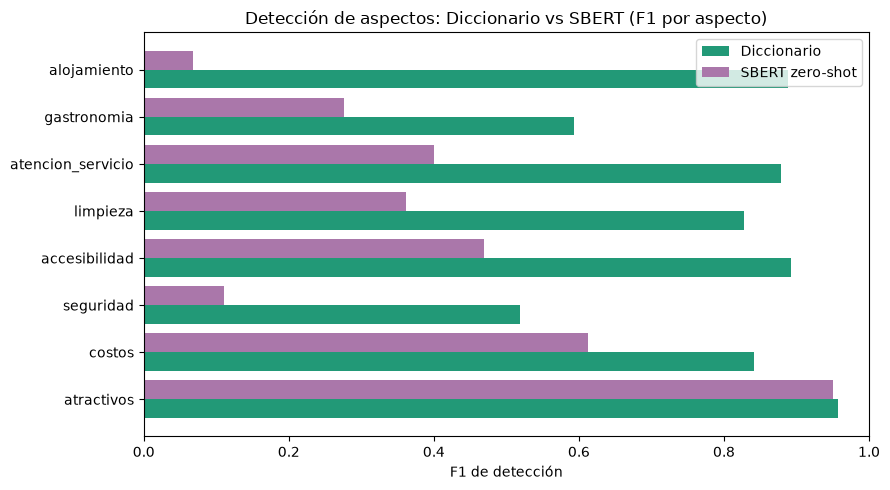

Figura NB03 -> outputs/figures/


In [5]:
# ============================================================
# VISUALIZACIÓN (figura para la tesis)
# ============================================================
import matplotlib.pyplot as plt
FIG = BASE_DIR / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

c = comp[comp["aspecto"] != "MACRO"].copy()
asp = c["aspecto"].tolist(); x = np.arange(len(asp)); w = 0.4
plt.figure(figsize=(9, 5))
plt.barh(x - w/2, c["F1_dict"].astype(float), w, label="Diccionario", color="#229977")
plt.barh(x + w/2, c["F1_sbert"].astype(float), w, label="SBERT zero-shot", color="#aa77aa")
plt.yticks(x, asp); plt.xlabel("F1 de detección"); plt.xlim(0, 1)
plt.title("Detección de aspectos: Diccionario vs SBERT (F1 por aspecto)")
plt.legend(); plt.tight_layout(); plt.savefig(FIG / "fase2_deteccion_dict_vs_sbert.png", dpi=300); plt.show()
print("Figura NB03 -> outputs/figures/")

## 5. Veredicto

In [6]:
# ============================================================
# RESUMEN / VEREDICTO
# ============================================================
f1d = float(m_dict[m_dict.aspecto=="MACRO"]["F1"].iloc[0])
f1s = float(m_sbert[m_sbert.aspecto=="MACRO"]["F1"].iloc[0])
print("="*56); print("DETECCIÓN DE ASPECTOS — VEREDICTO"); print("="*56)
print(f"F1-macro diccionario: {f1d:.3f}")
print(f"F1-macro SBERT:       {f1s:.3f}")
ganador = "SBERT" if f1s>f1d else ("diccionario" if f1d>f1s else "empate")
print(f"Ganador global: {ganador}")
print()
print("Por aspecto, gana:", comp.set_index("aspecto")["gana"].to_dict())
print()
print("Lectura honesta: este es el dato que decide qué detector usa la matriz (NB04+).")
print("Si SBERT no supera claramente al diccionario, se mantiene el diccionario (más simple y auditable).")

DETECCIÓN DE ASPECTOS — VEREDICTO
F1-macro diccionario: 0.800
F1-macro SBERT:       0.406
Ganador global: diccionario

Por aspecto, gana: {'atractivos': 'diccionario', 'costos': 'diccionario', 'seguridad': 'diccionario', 'accesibilidad': 'diccionario', 'limpieza': 'diccionario', 'atencion_servicio': 'diccionario', 'gastronomia': 'diccionario', 'alojamiento': 'diccionario', 'MACRO': 'diccionario'}

Lectura honesta: este es el dato que decide qué detector usa la matriz (NB04+).
Si SBERT no supera claramente al diccionario, se mantiene el diccionario (más simple y auditable).
